In [1]:
import rasterio
import numpy as np

import os
from google.colab import drive

# The stack and the patches live on Google Drive so they survive a Colab runtime reset
drive.mount('/content/drive')
DRIVE_DIR = '/content/drive/MyDrive/Coastal-Change-Detection'

# Path to the stack saved by data_collection.ipynb
tif_path = os.path.join(DRIVE_DIR, 'CycloneGabrielle_HawkesBay_S1_Stack_v2.tif')

with rasterio.open(tif_path) as src:
    print(f"Raster Dimensions: {src.width} x {src.height} pixels")
    print(f"Number of Bands  : {src.count}")
    print(f"CRS / Projection : {src.crs}")
    print(f"Spatial Resolution: {src.res} meters")
    print(f"Nodata value     : {src.nodata}")

    # Read all 6 bands
    # Band 1: pre_vv, Band 2: pre_vh, Band 3: post_vv, Band 4: post_vh, Band 5: vv_diff, Band 6: baseline_mask
    stack_data = src.read()

print("Data array shape (Bands, Height, Width):", stack_data.shape)

# Nodata is stored as -inf, so check with isfinite rather than isnan
valid = np.isfinite(stack_data).all(axis=0)
print(f"Pixels with data in every band: {100 * valid.mean():.1f}%")

Raster Dimensions: 4330 x 6667 pixels
Number of Bands  : 6
CRS / Projection : EPSG:32760
Spatial Resolution: (10.0, 10.0) meters
Nodata value     : -inf
Data array shape (Bands, Height, Width): (6, 6667, 4330)
Pixels with data in every band: 99.7%


In [2]:
import os
import json
import shutil
import rasterio
import numpy as np

# 1. Configuration
DRIVE_DIR = '/content/drive/MyDrive/Coastal-Change-Detection'  # Mounted in the first cell
tif_path = os.path.join(DRIVE_DIR, 'CycloneGabrielle_HawkesBay_S1_Stack_v2.tif')
base_dir = os.path.join(DRIVE_DIR, 'dataset_patches')

PATCH_SIZE = 256
STRIDE = 128       # 50% overlap between neighbouring patches
BLOCK_SIZE = 512  # Scene is cut into blocks; patches never cross a block edge
SPLITS = {'train': 0.70, 'val': 0.15, 'test': 0.15}
SEED = 42

# Input channels as 1-based band indices: pre_vv, pre_vh, post_vv, post_vh.
# vv_diff (band 5) is left out because baseline_mask is a threshold on it.
# pre_vv and post_vv still contain the same information, so this does not
# remove the label leakage on its own - that needs independent labels.
INPUT_BANDS = [1, 2, 3, 4]
MASK_BAND = 6

# 2. Read GeoTIFF and find valid pixels
with rasterio.open(tif_path) as src:
    features = src.read(INPUT_BANDS)  # Shape: (C, H, W)
    mask = src.read(MASK_BAND)        # Shape: (H, W)
    input_names = [src.descriptions[b - 1] for b in INPUT_BANDS]

# Nodata is written as -inf (not NaN), and some download tiles come back as all zeros
valid = np.isfinite(features).all(axis=0) & np.isfinite(mask) & ~(features == 0).all(axis=0)
print(f"Valid pixels: {100 * valid.mean():.1f}% of the scene")

_, height, width = features.shape

# 3. Sliding window inside each block, keeping only fully valid patches
blocks = {}
for by in range(0, height, BLOCK_SIZE):
    for bx in range(0, width, BLOCK_SIZE):
        y_end = min(by + BLOCK_SIZE, height)
        x_end = min(bx + BLOCK_SIZE, width)
        coords = [
            (y, x)
            for y in range(by, y_end - PATCH_SIZE + 1, STRIDE)
            for x in range(bx, x_end - PATCH_SIZE + 1, STRIDE)
            if valid[y:y + PATCH_SIZE, x:x + PATCH_SIZE].all()
        ]
        if coords:
            blocks[(by, bx)] = coords

if not blocks:
    raise ValueError("No fully valid patches found - re-export the GeoTIFF with data_collection.ipynb "
                     "and check its coverage before preprocessing.")

# 4. Assign whole blocks to splits, so overlapping patches never land in different splits.
# Flooding is concentrated in a few blocks, so try many random assignments and keep the one
# where each split's share of patches and of flooded pixels is closest to its target.
N_TRIALS = 20000
block_keys = list(blocks)
block_flood = {
    key: sum(int(mask[y:y + PATCH_SIZE, x:x + PATCH_SIZE].sum()) for y, x in blocks[key])
    for key in block_keys
}
patch_weights = np.array([len(blocks[key]) for key in block_keys], dtype=float)
flood_weights = np.array([block_flood[key] for key in block_keys], dtype=float)
targets = np.array(list(SPLITS.values()))

rng = np.random.default_rng(SEED)
best_score, best_choice = np.inf, None
for _ in range(N_TRIALS):
    choice = rng.choice(len(SPLITS), size=len(block_keys), p=targets)
    patch_share = np.bincount(choice, weights=patch_weights, minlength=len(SPLITS)) / patch_weights.sum()
    flood_share = np.bincount(choice, weights=flood_weights, minlength=len(SPLITS)) / max(flood_weights.sum(), 1)
    score = np.abs(patch_share - targets).sum() + np.abs(flood_share - targets).sum()
    if score < best_score:
        best_score, best_choice = score, choice

assignment = {
    name: [key for key, c in zip(block_keys, best_choice) if c == i]
    for i, name in enumerate(SPLITS)
}

# 5. Per-channel normalisation statistics from training pixels only
train_region = np.zeros((height, width), dtype=bool)
for key in assignment['train']:
    for y, x in blocks[key]:
        train_region[y:y + PATCH_SIZE, x:x + PATCH_SIZE] = True
train_values = features[:, train_region].astype(np.float64)
mean = train_values.mean(axis=1)
std = train_values.std(axis=1)
del train_values

for name, m, s in zip(input_names, mean, std):
    print(f"{name:<8} mean {m:7.2f} dB, std {s:5.2f} dB")

# 6. Save normalised patches to dataset_patches/<split>/{images,masks}
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)  # Clear patches from earlier runs so splits don't mix

for split, keys in assignment.items():
    images_dir = os.path.join(base_dir, split, 'images')
    masks_dir = os.path.join(base_dir, split, 'masks')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)

    patch_count = 0
    flooded_pixels = 0
    for key in keys:
        for y, x in blocks[key]:
            feature_patch = features[:, y:y + PATCH_SIZE, x:x + PATCH_SIZE]
            feature_patch = (feature_patch - mean[:, None, None]) / std[:, None, None]
            mask_patch = mask[y:y + PATCH_SIZE, x:x + PATCH_SIZE].astype(np.uint8)

            np.save(os.path.join(images_dir, f'patch_{patch_count:04d}.npy'), feature_patch.astype(np.float32))
            np.save(os.path.join(masks_dir, f'patch_{patch_count:04d}.npy'), mask_patch)

            flooded_pixels += int(mask_patch.sum())
            patch_count += 1

    flooded_pct = 100 * flooded_pixels / (patch_count * PATCH_SIZE ** 2) if patch_count else 0
    print(f"{split:<5}: {patch_count:4d} patches from {len(keys):2d} blocks, {flooded_pct:.2f}% flooded pixels")
    if patch_count == 0:
        print("       WARNING: empty split - reduce BLOCK_SIZE or check the GeoTIFF's coverage")

# 7. Record settings, normalisation and block assignment for training / inference
with open(os.path.join(base_dir, 'dataset_info.json'), 'w') as f:
    json.dump({
        'source': os.path.basename(tif_path),
        'input_bands': input_names,
        'patch_size': PATCH_SIZE,
        'stride': STRIDE,
        'block_size': BLOCK_SIZE,
        'seed': SEED,
        'normalisation': {'mean': mean.tolist(), 'std': std.tolist()},
        'blocks': {split: [list(key) for key in keys] for split, keys in assignment.items()},
    }, f, indent=2)

print(f"Patches saved to folder: '{base_dir}/'")

Valid pixels: 99.7% of the scene
pre_vv   mean  -13.72 dB, std  5.07 dB
pre_vh   mean  -19.91 dB, std  6.18 dB
post_vv  mean  -12.30 dB, std  5.73 dB
post_vh  mean  -18.26 dB, std  6.93 dB
train:  623 patches from 73 blocks, 1.47% flooded pixels
val  :  141 patches from 16 blocks, 1.36% flooded pixels
test :  129 patches from 15 blocks, 1.46% flooded pixels
Patches saved to folder: 'dataset_patches/'


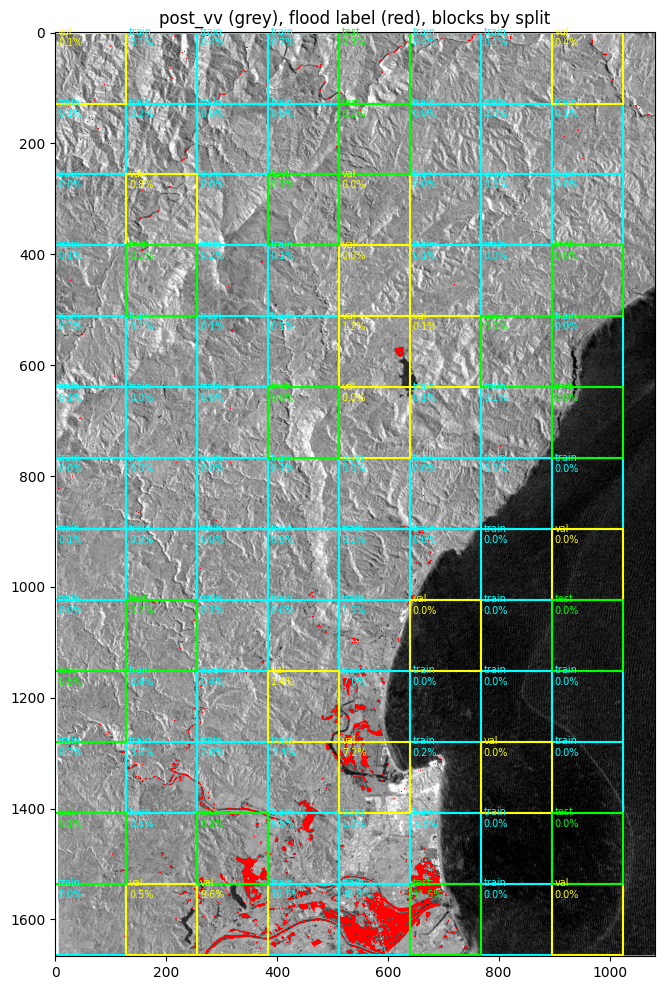

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

step = 4  # Downsample for display
fig, ax = plt.subplots(figsize=(8, 12))
post_vv = np.where(np.isfinite(features[2]), features[2], np.nan)[::step, ::step]
ax.imshow(post_vv, cmap='gray', vmin=-25, vmax=0)
flood = np.ma.masked_where(mask[::step, ::step] != 1, mask[::step, ::step])
ax.imshow(flood, cmap='autumn', interpolation='nearest')

colours = {'train': 'cyan', 'val': 'yellow', 'test': 'lime'}
for split, keys in assignment.items():
    for by, bx in keys:
        pct = 100 * block_flood[(by, bx)] / (len(blocks[(by, bx)]) * PATCH_SIZE ** 2)
        ax.add_patch(Rectangle((bx / step, by / step), BLOCK_SIZE / step, BLOCK_SIZE / step,
                               fill=False, edgecolor=colours[split], linewidth=1.5))
        ax.text(bx / step + 5, by / step + 25, f"{split}\n{pct:.1f}%", color=colours[split], fontsize=7)

ax.set_title('post_vv (grey), flood label (red), blocks by split')
plt.savefig(os.path.join(DRIVE_DIR, 'flood_mask_check.png'), dpi=150, bbox_inches='tight')
plt.show()


In [4]:
import glob

# Splits are fixed by spatial block in the previous cell; load each split's file lists
def split_paths(split):
    images = sorted(glob.glob(f'{base_dir}/{split}/images/*.npy'))
    masks = sorted(glob.glob(f'{base_dir}/{split}/masks/*.npy'))
    return images, masks

train_imgs, train_masks = split_paths('train')
val_imgs, val_masks = split_paths('val')
test_imgs, test_masks = split_paths('test')

print(f"Train Patches: {len(train_imgs)}")
print(f"Val Patches  : {len(val_imgs)}")
print(f"Test Patches : {len(test_imgs)}")

Train Patches: 623
Val Patches  : 141
Test Patches : 129
